In [201]:
import librosa as lbs
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os 
import matplotlib.pyplot as plt
import whisper
from transformers import AutoTokenizer 
import re
from pathlib import Path
from torch.utils.data import Dataset , DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd

# Assigning emotion labels

In [202]:
emo_labels = {
    "01" : "neutral",
    "02" : "calm",
    "03" : "happy",
    "04" : "sad",
    "05" : "angry",
    "06" : "fearful",
    "07" : "disgust",
    "08" : "surprised"
}
emo_maps = {
    "neutral" : 0,
    "calm" : 1,
    "happy" : 2,
    "sad" : 3,
    "angry" : 4,
    "fearful" : 5,
    "disgust" : 6,
    "surprised" : 7
}
emo_rev_maps = {
    0 : "neutral",
    1 : "calm",
    2 : "happy",
    3 : "sad",
    4 : "angry",
    5 : "fearful",
    6 : "disgust",
    7 : "surprised"
}

# Storing the emotions of each audio file

In [203]:
audio_dir = "audio_dataset"
audio_files = lbs.util.find_files(audio_dir , ext = ['wav'])
emotion = []
for i in range(len(audio_files)):
    name = os.path.basename(audio_files[i])
    name = re.split(r'[-]' , name)
    emotion.append(emo_labels.get(name[2] , "not_in_map"))


# Creating dataset for each audio file

In [204]:
audio_data = []
for _ in range(len(audio_files)):
    signal , sampling_rate = lbs.load(audio_files[_] , sr= 22050)
    audio_data.append({
        "file_name" : os.path.basename(audio_files[_]),
        "signal" : signal ,
        "sr" : sampling_rate,
        "emotion" : emo_maps.get(emotion[_] , -1)

    })
print(len(audio_data))
#showing the correct amount of audio files

1440


# Function to create log mel dataset and padding it according to the max column width 

In [205]:
def SpectroDataset(audio_data):
    S_mel = []
    for k in audio_data:
        S = lbs.feature.melspectrogram(y = k["signal"] , sr = k["sr"] , n_mels = 128)
        S1 = lbs.power_to_db(S , ref=np.max)
        S_mel.append(S1)
    max_s = np.max([S_mel[i].shape[1] for i in range(len(S_mel))])
    padded_mel = []
    for mel in S_mel:
        pad_width = max_s - mel.shape[1]
        mel_padded = np.pad(mel , ((0,0) , (0,pad_width)) , mode = "constant" , constant_values = 0)
        padded_mel.append(mel_padded)
    return padded_mel

# Creating a CNN model 

In [206]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN , self).__init__()
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3,3), padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32,  kernel_size=(3,3), padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=(3,3), padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=(3,3), padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d((2,2))
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4,4))
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Training the model  

In [207]:
def model_train(model , train_loader , val_loader , epochs = 20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    err_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters() , lr=0.0001,weight_decay= 0.00001)
    best_val_acc = 0
    loss_array_train= []
    val_acc_array = []
    val_loss_array = []
    for epoch in range(epochs):
        model.train()
        total_loss_train= 0.0
        correct = 0 
        total = 0 
        for mel,labels in train_loader:
            mel,labels = mel.to(device) , labels.to(device)
            optimizer.zero_grad()
            result = model(mel)
            loss = err_criterion(result , labels)
            loss.backward()
            optimizer.step()
            total_loss_train += loss.item()
            correct += (result.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_acc = correct/total
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            total_loss_val = 0.0
            for mel, labels in val_loader:
                mel, labels = mel.to(device), labels.to(device)
                outputs = model(mel)
                loss = err_criterion(outputs, labels)
                total_loss_val +=loss
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
            
        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {total_loss_train /len(train_loader):.4f} | "
              f"Train: {train_acc:.3f} | Val: {val_acc:.3f}")
        loss_array_train.append(total_loss_train /len(train_loader))
        val_acc_array.append(val_acc)
        val_loss_array.append(total_loss_val / len(val_loader))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        print(f"Best validation accuracy is : {best_val_acc}")
    plt.figure(figsize = (15, 10))
    x = np.arange(1, epochs + 1)
    fig , (ax1,ax2, ax3) = plt.subplots(3,1)
    ax1.plot(x, loss_array_train, c="yellow" , linewidth = 2)
    ax1.set_xlabel("No. of Epochs")
    ax1.set_ylabel("Total Loss")
    ax2.plot(x , val_acc_array , c = "pink" , linewidth = 2 )
    ax2.set_xlabel("No. of Epochs")
    ax2.set_ylabel("Total Validation Accuracy")
    ax3.plot(x , val_loss_array , color = "blue" , linewidth = 2)
    ax3.set_xlabel("No. of Epochs")
    ax3.set_ylabel("Total Validation Loss")
    plt.tight_layout()
    plt.savefig('cnn.png', bbox_inches='tight')
    plt.show()
    
    return  model , loss_array_train , val_acc_array , val_loss_array

In [208]:
def predict_emo(test_loader , model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    predicted_emo = [] 
    for mel, label in test_loader:
        mel_tensor = torch.FloatTensor(mel)
        mel_tensor = mel_tensor.to(device)
        with torch.no_grad():
            raw_scores = model(mel_tensor)
            probabilities = F.softmax(raw_scores , dim = 1)[0]
            pred_index = probabilities.argmax().item()
        emotion = emo_rev_maps.get(pred_index  , "not_in_map")
        predicted_emo.append(emotion)
    return predicted_emo


# Dataset and Dataloader

In [209]:
class MelDataSet(Dataset):
    def __init__(self , mel_d , emo):
        self.mel = mel_d 
        self.emo = emo 
    def __len__(self):
        return len(self.emo)
    def __getitem__(self , index):
        mel = self.mel[index]
        mel_tensor = torch.FloatTensor(mel)
        mel_tensor = mel_tensor.unsqueeze(0)
        emotion = self.emo[index] 
        return mel_tensor , emotion 

In [210]:
mel_train , mel_val , emo_train , emo_val = train_test_split(
    SpectroDataset(audio_data),
    [item["emotion"] for item in audio_data],
    test_size = 0.2,
    random_state = 42
)
train_loader = DataLoader(MelDataSet(mel_train , emo_train) , batch_size = 8 , shuffle = True)
val_loader = DataLoader(MelDataSet(mel_val , emo_val) , batch_size = 8 , shuffle = False)

# Training and Predicting

Epoch 01/50 | Loss: 2.0508 | Train: 0.164 | Val: 0.250
Best validation accuracy is : 0.25
Epoch 02/50 | Loss: 1.9898 | Train: 0.191 | Val: 0.260
Best validation accuracy is : 0.2604166666666667
Epoch 03/50 | Loss: 1.9487 | Train: 0.233 | Val: 0.337
Best validation accuracy is : 0.3368055555555556
Epoch 04/50 | Loss: 1.8487 | Train: 0.306 | Val: 0.389
Best validation accuracy is : 0.3888888888888889
Epoch 05/50 | Loss: 1.7438 | Train: 0.348 | Val: 0.462
Best validation accuracy is : 0.4618055555555556
Epoch 06/50 | Loss: 1.6409 | Train: 0.389 | Val: 0.469
Best validation accuracy is : 0.46875
Epoch 07/50 | Loss: 1.5801 | Train: 0.418 | Val: 0.434
Best validation accuracy is : 0.46875
Epoch 08/50 | Loss: 1.5258 | Train: 0.416 | Val: 0.507
Best validation accuracy is : 0.5069444444444444
Epoch 09/50 | Loss: 1.4725 | Train: 0.449 | Val: 0.472
Best validation accuracy is : 0.5069444444444444
Epoch 10/50 | Loss: 1.4426 | Train: 0.454 | Val: 0.507
Best validation accuracy is : 0.5069444444444

<Figure size 1500x1000 with 0 Axes>

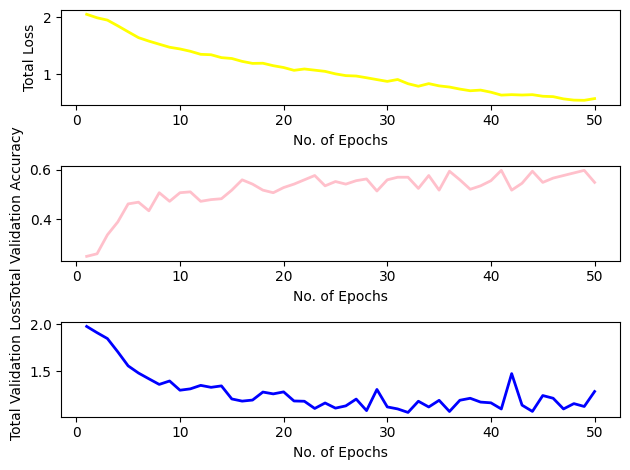

In [211]:
Epochs = 50
model = CNN()
model, loss , val_acc , val_loss = model_train(model , train_loader , val_loader , Epochs)
            

In [68]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = whisper.load_model("base").to(device)
text_data = []
for i in range(len(audio_data)):
    audio = lbs.resample(audio_data[i]["signal"] , orig_sr = audio_data[i]["sr"] , target_sr= 22050)
    result = model.transcribe(audio)
    text_data.append(result["text"]) 


C:\Users\divya\AppData\Roaming\Python\Python313\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


In [212]:
Data =    pd.DataFrame({ "transcript" : text_data ,"emotion" : [item["emotion"] for item in audio_data]})
Data.to_csv('whisper_transcripts.csv')
                       

In [213]:
data = pd.read_csv('whisper_transcripts.csv')
data.head()

,Unnamed: 0,transcript,emotion
0,0,Kids are talking by the door.,0
1,1,Kids are talking by the door.,0
2,2,Dogs are sitting by the door.,0
3,3,Dogs are sitting by the door.,0
4,4,Kids are talking by the door.,1


In [214]:
text = data['transcript'].to_numpy()
print(text.shape)


(1440,)


In [215]:
class RNN(nn.Module):
    def __init__(self , vocab_size , emb_dim , hid_dim=128):
        super(RNN ,self).__init__()
        self.emd = nn.Embedding(vocab_size , emb_dim)
        self.rnn = nn.LSTM(emb_dim , hid_dim , batch_first= True)
        self.fc = nn.Linear(hid_dim ,8)
    def forward(self, x):
        embedded = self.emd(x)
        result , (hidden ,cell) = self.rnn(embedded)
        final_hidden = hidden[-1 , : , :]
        return self.fc(final_hidden)

In [216]:
def train_RNN(model , train_loader , val_loader , epochs = 20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    err_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters() , lr=0.0001,weight_decay= 0.00001)
    best_val_acc = 0
    loss_array = []
    val_acc_array = []
    val_loss_array = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct , total = 0,0
        for text , label in train_loader:
            text = text.to(device)
            label = label.to(device)
            optimizer.zero_grad()
            output = model(text)
            loss = err_criterion(output , label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total += label.size(0)
            predicted = output.argmax(1)
            correct += (predicted == label).sum().item()
        train_acc = correct / total
        model.eval()
        val_correct , val_total = 0,0
        with torch.no_grad():
            total_loss_val = 0.0
            for text , emotion in val_loader:
                text = text.to(device)
                emotion = emotion.to(device).long()
                output = model(text)
                prediction = output.argmax(1)
                val_total += emotion.size(0)
                val_correct += (prediction == emotion).sum().item()
                loss = err_criterion(output ,emotion)
                total_loss_val+=loss
        val_acc = val_correct / val_total 

        print(f"Epoch:{epoch+1} | Loss:{total_loss/len(train_loader)} | Train Accuracy:{train_acc*100:.3f}% | Val Accuracy:{val_acc* 100 :.3f} %")
        loss_array.append(total_loss / len(train_loader))
        val_acc_array.append(val_acc)
        val_loss_array.append(total_loss_val / len(val_loader))
    
    plt.figure(figsize = (15, 10))
    x = np.arange(1, epochs + 1)
    fig , (ax1,ax2, ax3) = plt.subplots(3,1)
    ax1.plot(x, loss_array, c="yellow" , linewidth = 2)
    ax1.set_xlabel("No. of Epochs")
    ax1.set_ylabel("Total Loss")
    ax2.plot(x , val_acc_array , c = "pink" , linewidth = 2 )
    ax2.set_xlabel("No. of Epochs")
    ax2.set_ylabel("Total Validation Accuracy")
    ax3.plot(x , val_loss_array , color = "blue" , linewidth = 2)
    ax3.set_xlabel("No. of Epochs")
    ax3.set_ylabel("Total Validation Loss")
    plt.tight_layout()
    plt.savefig('rnn.png', bbox_inches='tight')
    plt.show()
    
    return model,loss_array,val_acc_array,val_loss_array

In [217]:
def predict_RNN(model , test_set):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    predictions = []
    with torch.no_grad():
        for text in test_set:
            text = text.to(device).unsqueeze(0)
            prediction = model(text)
            prediction = prediction.argmax(1)
            predictions.append(prediction)
    return predictions

In [218]:
class RNNdata(Dataset):
    def __init__(self , text , emotion):
        self.text = text
        self.emo = emotion
    def __len__(self):
        return len(self.emo)
    def __getitem__(self , index):
        text = self.text[index]
        text_tensor = torch.FloatTensor(text)
        emotion = self.emo[index]
        return text_tensor , emotion

In [219]:
X = data["transcript"].tolist()
y = data["emotion"].tolist()
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
X_tokenized=tokenizer(
    X,
    padding = True,
)
X_train , X_val , y_train , y_val = train_test_split(
    X_tokenized["input_ids"],
    y,
    test_size = 0.2 ,
    random_state = 42
)
train_loader = DataLoader(RNNdata(X_train , y_train) , batch_size = 16 , shuffle = True)
val_loader = DataLoader(RNNdata(X_val , y_val) , batch_size = 16 , shuffle = False)

In [220]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
vectorizer.fit(data['transcript'])
vocab_size = tokenizer.vocab_size
print(vocab_size)

30522


In [ ]:
Epochs = 50
emb_dim = 128
hid_dim = 128
model = RNN(vocab_size , emb_dim , hid_dim)
model , loss_Rnn , val_accRnn , val_lossRnn = train_RNN(model , train_loader , val_loader , epochs = Epochs)

In [ ]:
class Multimodel():
    def __init__(self , cnn , rnn , type = "average" ,pred = [])
        self.cnn = cnn
        self.rnn = rnn
        self.pred = pred
        if(type == "average"):
            self.average()
        elif(type == "weighted"):
            self.weighted()
        else:
            self.maximum()
        
        

    def softmaxfn(self , a):
        a = np.exp(a)
        sum_e= np.sum(a)
        return a/sum_e
    def average(self):
        softmax_a = self.softmaxfn(self.cnn_pred)
        softmax_b = self.softmaxfn(self.rnn_pred)
        average_pred =(softmax_a+softmax_b)/2
        return average_pred
    def weighted(self):
        softmax_a = self.softmaxfn(self.cnn_pred)
        softmax_b = self.softmaxfn(self.rnn_pred)
        weighted_pred= (softmax_a*0.7 + softmax_b*0.3)
        return weighted_pred
    def maximum(self):
        softmax_a = self.softmaxfn(self.cnn_pred)
        softmax_b = self.softmaxfn(self.rnn_pred)



        
